<a href="https://colab.research.google.com/github/sravanisagara2721/CodeTech-ML-Internship/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
reviews = [
    # positive reviews
    "This product is absolutely amazing, I love it so much",
    "Great quality, very happy with my purchase",
    "Excellent service and fast delivery, will buy again",
    "Totally worth the money, highly recommended",
    "The best product I have ever used, outstanding quality",
    "Very satisfied, it exceeded my expectations completely",
    "Awesome experience, the staff was super helpful and kind",
    "Really good value for money, works perfectly fine",
    "I am so happy with this purchase, fantastic item",
    "Five stars, brilliant product and smooth delivery",
    "Loved it! Will definitely recommend to my friends",
    "Perfect fit and great material, very comfortable",
    "Superb quality and quick shipping, totally satisfied",
    "Amazing product, works exactly as described online",
    "Wonderful experience, packaging was also very neat",
    "Good product, received on time, very happy overall",
    "Impressive quality for the price, will order again",
    "Outstanding customer support and excellent product",
    "Really pleased with this item, great value",
    "Delightful purchase, everything was smooth and easy",

    # negative reviews
    "This is the worst product I have ever bought, terrible",
    "Very disappointed, stopped working after just two days",
    "Horrible quality, broke immediately after first use",
    "Complete waste of money, do not buy this at all",
    "Terrible experience, customer service was very rude",
    "Really bad product, totally not worth the price",
    "I hate this product, it is useless and cheap",
    "Very poor quality, nothing like what was shown online",
    "Damaged item received, packaging was also broken",
    "Extremely disappointed, will never shop here again",
    "Awful product, it stopped working within a week",
    "Do not buy this, total scam and waste of money",
    "Bad experience, delivery was late and item was damaged",
    "Very unhappy with this purchase, worst ever",
    "Product is fake and very low quality, avoid it",
    "Disgusting quality, not at all as advertised online",
    "Terrible packaging, item arrived completely broken",
    "Very bad customer service, no response at all",
    "Worst shopping experience, will not come back here",
    "Poor build quality, fell apart within first few hours",
]

labels = [1]*20 + [0]*20   # 1 = positive, 0 = negative

df = pd.DataFrame({'review': reviews, 'sentiment': labels})
df['sentiment_label'] = df['sentiment'].map({1: 'Positive', 0: 'Negative'})

print("Dataset created!")
print("Shape:", df.shape)
print("\nSample data:")
print(df.head(5))
print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())


Dataset created!
Shape: (40, 3)

Sample data:
                                              review  sentiment  \
0  This product is absolutely amazing, I love it ...          1   
1         Great quality, very happy with my purchase          1   
2  Excellent service and fast delivery, will buy ...          1   
3        Totally worth the money, highly recommended          1   
4  The best product I have ever used, outstanding...          1   

  sentiment_label  
0        Positive  
1        Positive  
2        Positive  
3        Positive  
4        Positive  

Class Distribution:
sentiment_label
Positive    20
Negative    20
Name: count, dtype: int64


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                            # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)       # remove punctuation/numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return ' '.join(tokens)

df['cleaned'] = df['review'].apply(clean_text)

print("\nAfter Cleaning (sample):")
print(df[['review', 'cleaned']].head(3))



After Cleaning (sample):
                                              review  \
0  This product is absolutely amazing, I love it ...   
1         Great quality, very happy with my purchase   
2  Excellent service and fast delivery, will buy ...   

                                cleaned  
0  product absolutely amazing love much  
1          great quality happy purchase  
2   excellent service fast delivery buy  


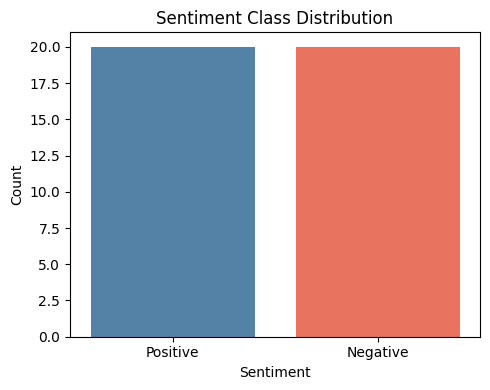

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(x='sentiment_label', data=df,
              palette={'Positive': 'steelblue', 'Negative': 'tomato'})
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

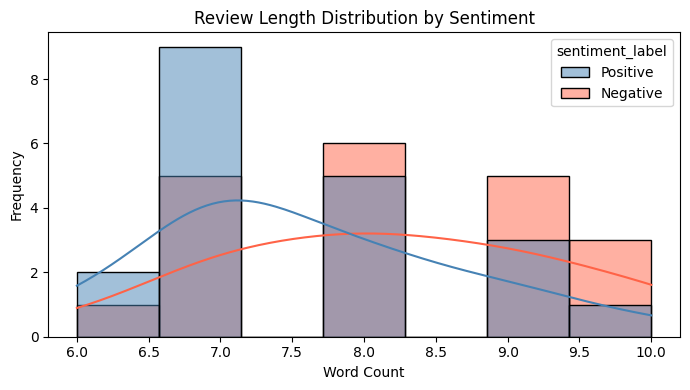

In [ ]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='review_length', hue='sentiment_label',
             kde=True, palette={'Positive': 'steelblue', 'Negative': 'tomato'})
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
X = df['cleaned']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF converts text into numerical feature vectors
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("\nTF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test) :", X_test_tfidf.shape)



TF-IDF matrix shape (train): (32, 236)
TF-IDF matrix shape (test) : (8, 236)


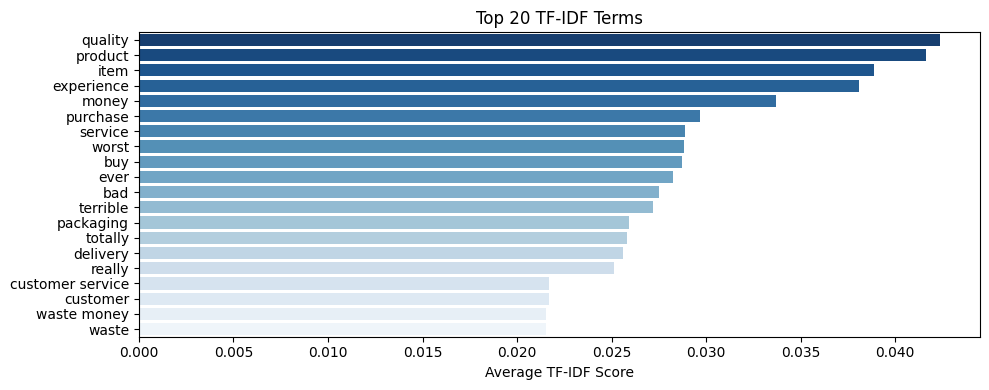

In [ ]:
feature_names = tfidf.get_feature_names_out()
tfidf_scores  = X_train_tfidf.toarray().mean(axis=0)
top_indices   = tfidf_scores.argsort()[-20:][::-1]
top_terms     = [feature_names[i] for i in top_indices]
top_scores    = [tfidf_scores[i] for i in top_indices]

plt.figure(figsize=(10, 4))
sns.barplot(x=top_scores, y=top_terms, palette='Blues_r')
plt.title('Top 20 TF-IDF Terms')
plt.xlabel('Average TF-IDF Score')
plt.tight_layout()
plt.show()

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

print("\nModel training done!")


Model training done!


In [ ]:
y_pred = model.predict(X_test_tfidf)
acc    = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Test Accuracy: 75.00%

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67         4
    Positive       0.67      1.00      0.80         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



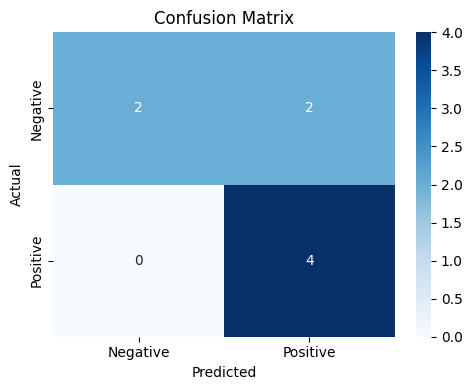

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

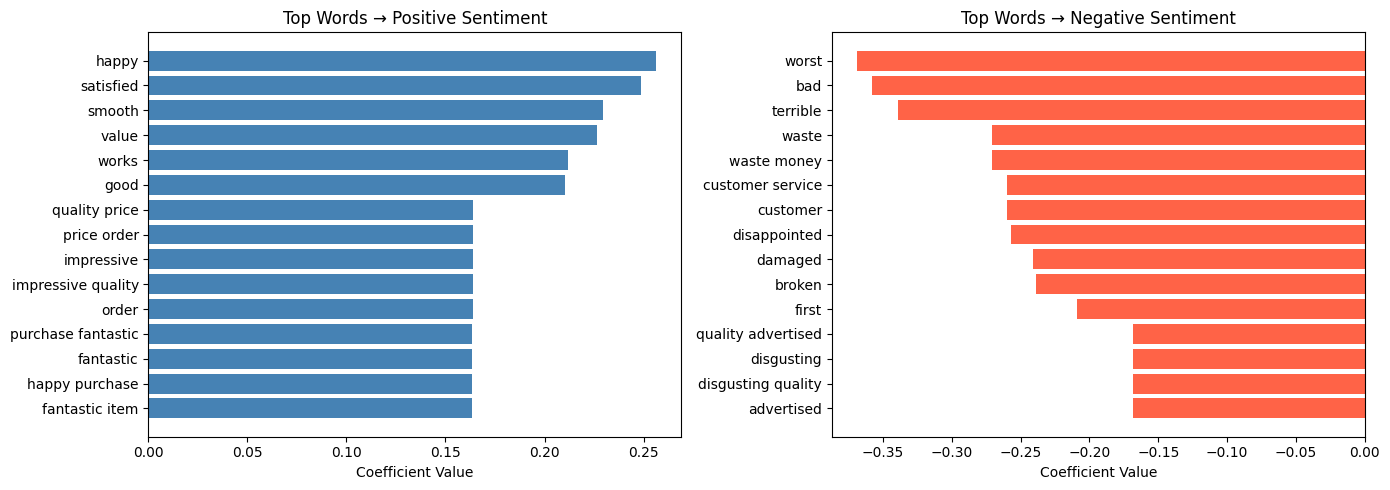

In [ ]:
coef        = model.coef_[0]
top_pos_idx = coef.argsort()[-15:][::-1]
top_neg_idx = coef.argsort()[:15]

top_pos_words  = [feature_names[i] for i in top_pos_idx]
top_pos_scores = [coef[i] for i in top_pos_idx]
top_neg_words  = [feature_names[i] for i in top_neg_idx]
top_neg_scores = [coef[i] for i in top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos_words[::-1], top_pos_scores[::-1], color='steelblue')
axes[0].set_title('Top Words → Positive Sentiment')
axes[0].set_xlabel('Coefficient Value')

axes[1].barh(top_neg_words[::-1], top_neg_scores[::-1], color='tomato')
axes[1].set_title('Top Words → Negative Sentiment')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(text):
    cleaned  = clean_text(text)
    vectored = tfidf.transform([cleaned])
    pred     = model.predict(vectored)[0]
    proba    = model.predict_proba(vectored)[0]
    label    = "POSITIVE 😊" if pred == 1 else "NEGATIVE 😞"
    print(f"\nReview   : {text}")
    print(f"Sentiment: {label}")
    print(f"Confidence: Positive={proba[1]:.2f}, Negative={proba[0]:.2f}")
predict_sentiment("The product quality is really good and I loved it")
predict_sentiment("Very bad experience, I will never buy this again")
predict_sentiment("Average product, nothing special about it but ok")



Review   : The product quality is really good and I loved it
Sentiment: POSITIVE 😊
Confidence: Positive=0.58, Negative=0.42

Review   : Very bad experience, I will never buy this again
Sentiment: NEGATIVE 😞
Confidence: Positive=0.41, Negative=0.59

Review   : Average product, nothing special about it but ok
Sentiment: POSITIVE 😊
Confidence: Positive=0.54, Negative=0.46
